In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root, len(files), 'files')
    if len(files) > 3:
        break

/kaggle/input 0 files
/kaggle/input/datasets 0 files
/kaggle/input/datasets/sreehithakorrapati 0 files
/kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo 1 files
/kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo/exdark_split 0 files
/kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo/exdark_split/val 0 files
/kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo/exdark_split/val/labels 1800 files


In [2]:
!pip install -q ultralytics albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:00


In [3]:
import yaml

DATASET_ROOT = "/kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo"

CLASS_NAMES = [
    "Bicycle", "Boat", "Bottle", "Bus", "Car", "Cat",
    "Chair", "Cup", "Dog", "Motorbike", "People", "Table"
]

data_yaml = {
    "path": DATASET_ROOT,
    "train": "exdark_split/train/images",
    "val": "exdark_split/val/images",
    "test": "exdark_split/test/images",
    "nc": len(CLASS_NAMES),
    "names": {i: name for i, name in enumerate(CLASS_NAMES)},
}

# Kaggle's working directory IS writable, unlike /kaggle/input
yaml_path = "/kaggle/working/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"Wrote {yaml_path}")
with open(yaml_path) as f:
    print(f.read())

Wrote /kaggle/working/data.yaml
path: /kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo
train: exdark_split/train/images
val: exdark_split/val/images
test: exdark_split/test/images
nc: 12
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table



In [4]:
import os
import shutil
import yaml

IMAGES_DATASET_ROOT = "/kaggle/input/datasets/sreehithakorrapati/exdark-processed-yolo/exdark_split"
LABELS_DATASET_ROOT = "/kaggle/input/datasets/sreehithakorrapati/exdark-person-labels/exdark_person_labels"
WORKING_ROOT = "/kaggle/working/exdark_person_dataset"

for split_name in ("train", "val", "test"):
    images_src = os.path.join(IMAGES_DATASET_ROOT, split_name, "images")
    labels_src = os.path.join(LABELS_DATASET_ROOT, split_name, "labels")

    images_dst = os.path.join(WORKING_ROOT, split_name, "images")
    labels_dst = os.path.join(WORKING_ROOT, split_name, "labels")

    os.makedirs(os.path.dirname(images_dst), exist_ok=True)

    # Copying directly (symlinking the whole folder was unreliable on Kaggle)
    if not os.path.exists(images_dst):
        print(f"Copying images for {split_name} (this may take a minute)...")
        shutil.copytree(images_src, images_dst)

    if not os.path.exists(labels_dst):
        shutil.copytree(labels_src, labels_dst)

    n_images = len(os.listdir(images_dst))
    n_labels = len(os.listdir(labels_dst))
    print(f"{split_name}: {n_images} images (copied), {n_labels} labels (copied)")

data_yaml = {
    "path": WORKING_ROOT,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 1,
    "names": {0: "person"},
}

yaml_path = "/kaggle/working/data_person.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"\nWrote {yaml_path}")
with open(yaml_path) as f:
    print(f.read())

Copying images for train (this may take a minute)...
train: 3000 images (copied), 3000 labels (copied)
Copying images for val (this may take a minute)...
val: 1800 images (copied), 1800 labels (copied)
Copying images for test (this may take a minute)...
test: 2563 images (copied), 2563 labels (copied)

Wrote /kaggle/working/data_person.yaml
path: /kaggle/working/exdark_person_dataset
train: train/images
val: val/images
test: test/images
nc: 1
names:
  0: person



In [5]:
from ultralytics import YOLO
import pandas as pd
import time

model = YOLO("yolov8s.pt")

DATA_YAML = "/kaggle/working/data_person.yaml"

start_time = time.time()

results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    save_json=True,
    plots=True,
    single_cls=True,
)

elapsed = time.time() - start_time

print("=" * 50)
print("BASELINE (Condition A) RESULTS -- Person-only, corrected")
print("=" * 50)
print(f"mAP@0.5:      {results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {results.box.map:.4f}")
print(f"Precision:    {results.box.mp:.4f}")
print(f"Recall:       {results.box.mr:.4f}")
print(f"Total inference time: {elapsed:.1f} sec")
print(f"Avg inference time per image: {results.speed['inference']:.2f} ms")

metrics_summary = {
    "condition": "A_baseline_no_finetune",
    "model": "yolov8s_coco_pretrained",
    "map50": results.box.map50,
    "map50_95": results.box.map,
    "precision": results.box.mp,
    "recall": results.box.mr,
    "inference_ms_per_image": results.speed["inference"],
    "total_inference_time_sec": elapsed,
}

df = pd.DataFrame([metrics_summary])
df.to_csv("/kaggle/working/all_runs_metrics.csv", index=False)
print("\nSaved metrics to /kaggle/working/all_runs_metrics.csv")
print(df)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2119.2±1010.4 MB/s, size: 290.1 KB)
val: Scanning /kaggle/working/exdark_person_dataset/test/labels... 2563 images, 1722 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 724.7it/s 3.5s
val: /kaggle/working/exdark_person_dataset/test/images/2015_03579.jpg: corrupt JPEG restored and saved
val: /kaggle/working/exdark_person_dataset/test/images/2015_03651.jpg: corrupt JPEG restored and saved
val: /kaggle/working/exdark_person_dataset/test/images/2015_05388.jpg: corrup

In [6]:
import os
import cv2
import shutil

def apply_clahe(image, clip_limit=3.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l)
    lab_enhanced = cv2.merge((l_enhanced, a, b))
    return cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)

SRC_ROOT = "/kaggle/working/exdark_person_dataset"
CLAHE_ROOT = "/kaggle/working/exdark_person_dataset_clahe"

for split_name in ("train", "val", "test"):
    src_images = os.path.join(SRC_ROOT, split_name, "images")
    dst_images = os.path.join(CLAHE_ROOT, split_name, "images")
    dst_labels = os.path.join(CLAHE_ROOT, split_name, "labels")
    src_labels = os.path.join(SRC_ROOT, split_name, "labels")

    os.makedirs(dst_images, exist_ok=True)
    if not os.path.exists(dst_labels):
        shutil.copytree(src_labels, dst_labels)

    image_files = os.listdir(src_images)
    print(f"Applying CLAHE to {len(image_files)} images in {split_name}...")

    for i, fname in enumerate(image_files):
        src_path = os.path.join(src_images, fname)
        dst_path = os.path.join(dst_images, fname)
        if os.path.exists(dst_path):
            continue
        img = cv2.imread(src_path)
        if img is None:
            print(f"  [SKIP] Could not read {src_path}")
            continue
        enhanced = apply_clahe(img)
        cv2.imwrite(dst_path, enhanced)
        if (i + 1) % 1000 == 0:
            print(f"  ...{i + 1}/{len(image_files)} done")

    print(f"[OK] {split_name} CLAHE preprocessing complete")

import yaml
data_yaml = {
    "path": CLAHE_ROOT,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 1,
    "names": {0: "person"},
}
yaml_path = "/kaggle/working/data_person_clahe.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)
print(f"Wrote {yaml_path}")

Applying CLAHE to 3000 images in train...
  ...1000/3000 done
  ...2000/3000 done
  ...3000/3000 done
[OK] train CLAHE preprocessing complete
Applying CLAHE to 1800 images in val...
  ...1000/1800 done
[OK] val CLAHE preprocessing complete
Applying CLAHE to 2563 images in test...
  ...1000/2563 done
  ...2000/2563 done
[OK] test CLAHE preprocessing complete
Wrote /kaggle/working/data_person_clahe.yaml


In [7]:
from ultralytics import YOLO
import pandas as pd
import os

model = YOLO("yolov8s.pt")
DATA_YAML = "/kaggle/working/data_person_clahe.yaml"

train_results = model.train(
    data=DATA_YAML,
    
    epochs=50,
    patience=15,   # stop early if val mAP hasn't improved in 15 epochs
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    device=0,
    project="/kaggle/working/runs_train",
    name="run_B_clahe_only",
    mosaic=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    flipud=0.0, fliplr=0.0, mixup=0.0,
)

val_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    single_cls=True,
)

metrics_row = {
    "condition": "B_clahe_only",
    "model": "yolov8s_finetuned",
    "map50": val_results.box.map50,
    "map50_95": val_results.box.map,
    "precision": val_results.box.mp,
    "recall": val_results.box.mr,
    "inference_ms_per_image": val_results.speed["inference"],
}

csv_path = "/kaggle/working/all_runs_metrics.csv"
existing_df = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
updated_df = pd.concat([existing_df, pd.DataFrame([metrics_row])], ignore_index=True)
updated_df.to_csv(csv_path, index=False)

print("RUN B (CLAHE only) RESULTS")
print(updated_df)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_person_clahe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run_B_clahe_only, nbs=64, nms=False, opset=N

In [8]:
import os
import cv2
import shutil
import albumentations as A

def build_augmentation_pipeline(p_gamma=0.5, p_noise=0.5, p_motion_blur=0.4, p_bilateral=0.3):
    def _bilateral_filter(image, **kwargs):
        return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    return A.Compose([
        A.RandomGamma(gamma_limit=(130, 200), p=p_gamma),
        A.GaussNoise(std_range=(0.04, 0.12), p=p_noise),
        A.MotionBlur(blur_limit=(3, 7), p=p_motion_blur),
        A.Lambda(image=_bilateral_filter, p=p_bilateral),
    ])

SRC_ROOT = "/kaggle/working/exdark_person_dataset"          # original raw images
AUG_ROOT = "/kaggle/working/exdark_person_dataset_aug"       # augmented train/val copy

pipeline = build_augmentation_pipeline()

for split_name in ("train", "val"):   # NOTE: test is intentionally excluded -- stays raw
    src_images = os.path.join(SRC_ROOT, split_name, "images")
    dst_images = os.path.join(AUG_ROOT, split_name, "images")
    dst_labels = os.path.join(AUG_ROOT, split_name, "labels")
    src_labels = os.path.join(SRC_ROOT, split_name, "labels")

    os.makedirs(dst_images, exist_ok=True)
    if not os.path.exists(dst_labels):
        shutil.copytree(src_labels, dst_labels)

    image_files = os.listdir(src_images)
    print(f"Applying augmentation to {len(image_files)} images in {split_name}...")

    for i, fname in enumerate(image_files):
        src_path = os.path.join(src_images, fname)
        dst_path = os.path.join(dst_images, fname)
        if os.path.exists(dst_path):
            continue
        img = cv2.imread(src_path)
        if img is None:
            print(f"  [SKIP] Could not read {src_path}")
            continue
        augmented = pipeline(image=img)["image"]
        cv2.imwrite(dst_path, augmented)
        if (i + 1) % 1000 == 0:
            print(f"  ...{i + 1}/{len(image_files)} done")

    print(f"[OK] {split_name} augmentation complete")

# data.yaml: train/val point to augmented copy, test points to ORIGINAL raw images
import yaml
data_yaml = {
    "train": os.path.join(AUG_ROOT, "train/images"),
    "val": os.path.join(AUG_ROOT, "val/images"),
    "test": os.path.join(SRC_ROOT, "test/images"),   # raw, untouched
    "nc": 1,
    "names": {0: "person"},
}
yaml_path = "/kaggle/working/data_person_aug.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)
print(f"Wrote {yaml_path}")

Applying augmentation to 3000 images in train...
  ...1000/3000 done
  ...2000/3000 done
  ...3000/3000 done
[OK] train augmentation complete
Applying augmentation to 1800 images in val...
  ...1000/1800 done
[OK] val augmentation complete
Wrote /kaggle/working/data_person_aug.yaml


In [9]:
from ultralytics import YOLO
import pandas as pd
import os

model = YOLO("yolov8s.pt")
DATA_YAML = "/kaggle/working/data_person_aug.yaml"

train_results = model.train(
    data=DATA_YAML,
    epochs=50,
    patience=15,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    device=0,
    project="/kaggle/working/runs_train",
    name="run_C_aug_only",
    # Disable Ultralytics' own built-in augmentations -- isolating OUR
    # custom nighttime augmentation pipeline's effect alone
    mosaic=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    flipud=0.0, fliplr=0.0, mixup=0.0,
)

val_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    single_cls=True,
)

metrics_row = {
    "condition": "C_augmentation_only",
    "model": "yolov8s_finetuned",
    "map50": val_results.box.map50,
    "map50_95": val_results.box.map,
    "precision": val_results.box.mp,
    "recall": val_results.box.mr,
    "inference_ms_per_image": val_results.speed["inference"],
}

csv_path = "/kaggle/working/all_runs_metrics.csv"
existing_df = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
updated_df = pd.concat([existing_df, pd.DataFrame([metrics_row])], ignore_index=True)
updated_df.to_csv(csv_path, index=False)

print("RUN C (Augmentation only) RESULTS")
print(updated_df)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_person_aug.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run_C_aug_only, nbs=64, nms=False, opset=None,

In [10]:
from ultralytics import YOLO
import pandas as pd
import os

# Same pretrained COCO weights as Condition A -- no fine-tuning
model = YOLO("yolov8s.pt")

# Reuses the CLAHE-preprocessed test set already built in Cell 6
DATA_YAML = "/kaggle/working/data_person_clahe.yaml"

results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    single_cls=True,
)

print("=" * 50)
print("CONDITION A2 RESULTS -- CLAHE at inference only, NO fine-tuning")
print("=" * 50)
print(f"mAP@0.5:      {results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {results.box.map:.4f}")
print(f"Precision:    {results.box.mp:.4f}")
print(f"Recall:       {results.box.mr:.4f}")

metrics_row = {
    "condition": "A2_baseline_clahe_no_finetune",
    "model": "yolov8s_coco_pretrained",
    "map50": results.box.map50,
    "map50_95": results.box.map,
    "precision": results.box.mp,
    "recall": results.box.mr,
    "inference_ms_per_image": results.speed["inference"],
}

csv_path = "/kaggle/working/all_runs_metrics.csv"
existing_df = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
updated_df = pd.concat([existing_df, pd.DataFrame([metrics_row])], ignore_index=True)
updated_df.to_csv(csv_path, index=False)

print(updated_df)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1629.6±741.4 MB/s, size: 278.3 KB)
val: Scanning /kaggle/working/exdark_person_dataset_clahe/test/labels.cache... 2563 images, 1722 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 632.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 161/161 5.7it/s 28.3s
                   all       2563       2235      0.281      0.585      0.235      0.119
                person        841       2235      0.281      0.585      0.235      0.119
Speed: 0.7ms preprocess, 6.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-4
CONDITION A2 RESULTS -- CLAHE at inference only, NO fine-tuning
mAP@0.5:      0.2353
mAP@0.5:0.95: 0.1188
Precision:    0.2813
Recall:       

In [11]:
import os
import cv2
import shutil
import albumentations as A

def build_augmentation_pipeline(p_gamma=0.5, p_noise=0.5, p_motion_blur=0.4, p_bilateral=0.3):
    def _bilateral_filter(image, **kwargs):
        return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    return A.Compose([
        A.RandomGamma(gamma_limit=(130, 200), p=p_gamma),
        A.GaussNoise(std_range=(0.04, 0.12), p=p_noise),
        A.MotionBlur(blur_limit=(3, 7), p=p_motion_blur),
        A.Lambda(image=_bilateral_filter, p=p_bilateral),
    ])

CLAHE_ROOT = "/kaggle/working/exdark_person_dataset_clahe"       # already built in Cell 6
CLAHE_AUG_ROOT = "/kaggle/working/exdark_person_dataset_clahe_aug"

pipeline = build_augmentation_pipeline()

for split_name in ("train", "val"):   # test stays CLAHE-only, no augmentation -- matches Run B's test setup
    src_images = os.path.join(CLAHE_ROOT, split_name, "images")
    dst_images = os.path.join(CLAHE_AUG_ROOT, split_name, "images")
    dst_labels = os.path.join(CLAHE_AUG_ROOT, split_name, "labels")
    src_labels = os.path.join(CLAHE_ROOT, split_name, "labels")

    os.makedirs(dst_images, exist_ok=True)
    if not os.path.exists(dst_labels):
        shutil.copytree(src_labels, dst_labels)

    image_files = os.listdir(src_images)
    print(f"Applying augmentation to CLAHE'd {split_name} images ({len(image_files)})...")

    for i, fname in enumerate(image_files):
        src_path = os.path.join(src_images, fname)
        dst_path = os.path.join(dst_images, fname)
        if os.path.exists(dst_path):
            continue
        img = cv2.imread(src_path)
        if img is None:
            print(f"  [SKIP] Could not read {src_path}")
            continue
        augmented = pipeline(image=img)["image"]
        cv2.imwrite(dst_path, augmented)
        if (i + 1) % 1000 == 0:
            print(f"  ...{i + 1}/{len(image_files)} done")

    print(f"[OK] {split_name} CLAHE+augmentation complete")

# test: reuse the CLAHE-only test set already built in Cell 6 (no augmentation on test)
import yaml
data_yaml = {
    "train": os.path.join(CLAHE_AUG_ROOT, "train/images"),
    "val": os.path.join(CLAHE_AUG_ROOT, "val/images"),
    "test": os.path.join(CLAHE_ROOT, "test/images"),
    "nc": 1,
    "names": {0: "person"},
}
yaml_path = "/kaggle/working/data_person_clahe_aug.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)
print(f"Wrote {yaml_path}")

Applying augmentation to CLAHE'd train images (3000)...
  ...1000/3000 done
  ...2000/3000 done
  ...3000/3000 done
[OK] train CLAHE+augmentation complete
Applying augmentation to CLAHE'd val images (1800)...
  ...1000/1800 done
[OK] val CLAHE+augmentation complete
Wrote /kaggle/working/data_person_clahe_aug.yaml


In [12]:
from ultralytics import YOLO
import pandas as pd
import os

model = YOLO("yolov8s.pt")
DATA_YAML = "/kaggle/working/data_person_clahe_aug.yaml"

train_results = model.train(
    data=DATA_YAML,
    epochs=50,
    patience=15,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    device=0,
    project="/kaggle/working/runs_train",
    name="run_D_clahe_and_aug",
    mosaic=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    flipud=0.0, fliplr=0.0, mixup=0.0,
)

val_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    single_cls=True,
)

metrics_row = {
    "condition": "D_clahe_and_augmentation",
    "model": "yolov8s_finetuned",
    "map50": val_results.box.map50,
    "map50_95": val_results.box.map,
    "precision": val_results.box.mp,
    "recall": val_results.box.mr,
    "inference_ms_per_image": val_results.speed["inference"],
}

csv_path = "/kaggle/working/all_runs_metrics.csv"
existing_df = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
updated_df = pd.concat([existing_df, pd.DataFrame([metrics_row])], ignore_index=True)
updated_df.to_csv(csv_path, index=False)

print("RUN D (CLAHE + Augmentation) RESULTS")
print(updated_df)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_person_clahe_aug.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run_D_clahe_and_aug, nbs=64, nms=False, 

In [13]:
from ultralytics import YOLO
import pandas as pd
import os

# Same CLAHE-preprocessed dataset used in Run B -- only the model architecture changes
model = YOLO("yolov9s.pt")

DATA_YAML = "/kaggle/working/data_person_clahe.yaml"

train_results = model.train(
    data=DATA_YAML,
    epochs=50,
    patience=15,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    device=0,
    project="/kaggle/working/runs_train",
    name="run_E_yolov9_clahe",
    mosaic=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    flipud=0.0, fliplr=0.0, mixup=0.0,
)

val_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    single_cls=True,
)

metrics_row = {
    "condition": "E_yolov9_clahe",
    "model": "yolov9s_finetuned",
    "map50": val_results.box.map50,
    "map50_95": val_results.box.map,
    "precision": val_results.box.mp,
    "recall": val_results.box.mr,
    "inference_ms_per_image": val_results.speed["inference"],
}

csv_path = "/kaggle/working/all_runs_metrics.csv"
existing_df = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
updated_df = pd.concat([existing_df, pd.DataFrame([metrics_row])], ignore_index=True)
updated_df.to_csv(csv_path, index=False)

print("RUN E (YOLOv9 + CLAHE) RESULTS")
print(updated_df)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_person_clahe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run_E_yolov9_clahe, nbs=64, nms=False, opset

In [14]:
import zipfile
import os

WEIGHTS_TO_COLLECT = {
    "run_B_clahe_only": "/kaggle/working/runs_train/run_B_clahe_only/weights/best.pt",
    "run_C_aug_only": "/kaggle/working/runs_train/run_C_aug_only/weights/best.pt",
    "run_D_clahe_and_aug": "/kaggle/working/runs_train/run_D_clahe_and_aug/weights/best.pt",
    "run_E_yolov9_clahe": "/kaggle/working/runs_train/run_E_yolov9_clahe/weights/best.pt",
}

ZIP_PATH = "/kaggle/working/all_trained_weights.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for run_name, weight_path in WEIGHTS_TO_COLLECT.items():
        if os.path.exists(weight_path):
            zipf.write(weight_path, arcname=f"{run_name}_best.pt")
            print(f"[OK] Added {run_name}")
        else:
            print(f"[MISSING] {weight_path} not found -- skipping")

# Also grab the metrics CSV while we're at it
metrics_path = "/kaggle/working/all_runs_metrics.csv"
if os.path.exists(metrics_path):
    with zipfile.ZipFile(ZIP_PATH, "a", zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(metrics_path, arcname="all_runs_metrics.csv")
    print("[OK] Added all_runs_metrics.csv")

size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"\nDone. {ZIP_PATH} ({size_mb:.1f} MB)")

[OK] Added run_B_clahe_only
[OK] Added run_C_aug_only
[OK] Added run_D_clahe_and_aug
[OK] Added run_E_yolov9_clahe
[OK] Added all_runs_metrics.csv

Done. /kaggle/working/all_trained_weights.zip (72.4 MB)


In [15]:
import os
import shutil

# Adjust this path once you confirm the mount location
SUBSETS_DATASET_ROOT = "/kaggle/input/datasets/sreehithakorrapati/exdark-daynight-subsets"

CLAHE_TEST_ROOT = "/kaggle/working/exdark_person_dataset_clahe/test"
SUBSET_WORKING_ROOT = "/kaggle/working/daynight_subsets"

def build_subset(name, filenames_txt):
    with open(filenames_txt) as f:
        filenames = [line.strip() for line in f if line.strip()]

    img_dst = os.path.join(SUBSET_WORKING_ROOT, name, "images")
    lbl_dst = os.path.join(SUBSET_WORKING_ROOT, name, "labels")
    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    copied = 0
    for fname in filenames:
        src_img = os.path.join(CLAHE_TEST_ROOT, "images", fname)
        base_name = os.path.splitext(fname)[0]
        src_lbl = os.path.join(CLAHE_TEST_ROOT, "labels", base_name + ".txt")

        if os.path.exists(src_img) and os.path.exists(src_lbl):
            shutil.copy2(src_img, os.path.join(img_dst, fname))
            shutil.copy2(src_lbl, os.path.join(lbl_dst, base_name + ".txt"))
            copied += 1

    print(f"{name}: {copied}/{len(filenames)} images copied")
    return img_dst

very_dark_images = build_subset(
    "very_dark",
    os.path.join(SUBSETS_DATASET_ROOT, "subset_very_dark_filenames.txt")
)
less_dark_images = build_subset(
    "less_dark",
    os.path.join(SUBSETS_DATASET_ROOT, "subset_less_dark_filenames.txt")
)

# Write a data.yaml for each subset
import yaml

for name, images_path in [("very_dark", very_dark_images), ("less_dark", less_dark_images)]:
    data_yaml = {
        "path": os.path.join(SUBSET_WORKING_ROOT, name),
        "train": "images",  # unused, but required by schema
        "val": "images",
        "test": "images",
        "nc": 1,
        "names": {0: "person"},
    }
    yaml_path = f"/kaggle/working/data_{name}.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)
    print(f"Wrote {yaml_path}")

very_dark: 1203/1203 images copied
less_dark: 335/335 images copied
Wrote /kaggle/working/data_very_dark.yaml
Wrote /kaggle/working/data_less_dark.yaml


In [16]:
from ultralytics import YOLO
import pandas as pd
import os

model = YOLO("/kaggle/working/runs_train/run_E_yolov9_clahe/weights/best.pt")

rows = []
for name in ("very_dark", "less_dark"):
    results = model.val(
        data=f"/kaggle/working/data_{name}.yaml",
        split="test",
        imgsz=640,
        batch=16,
        device=0,
        single_cls=True,
    )
    rows.append({
        "subset": name,
        "map50": results.box.map50,
        "map50_95": results.box.map,
        "precision": results.box.mp,
        "recall": results.box.mr,
    })
    print(f"\n{name}: mAP@0.5={results.box.map50:.4f}, mAP@0.5:0.95={results.box.map:.4f}, "
          f"P={results.box.mp:.4f}, R={results.box.mr:.4f}")

df = pd.DataFrame(rows)
df.to_csv("/kaggle/working/daynight_gap_results.csv", index=False)
print("\n" + "=" * 50)
print("DAY/NIGHT GAP ANALYSIS -- Run E model")
print("=" * 50)
print(df)

gap = df.loc[df["subset"]=="less_dark","map50_95"].values[0] - df.loc[df["subset"]=="very_dark","map50_95"].values[0]
print(f"\nmAP@0.5:0.95 gap (less_dark - very_dark): {gap:.4f}")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv9s summary (fused): 197 layers, 7,167,475 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2227.6±726.5 MB/s, size: 175.2 KB)
val: Scanning /kaggle/working/daynight_subsets/very_dark/labels... 1203 images, 923 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1203/1203 618.0it/s 1.9s
val: New cache created: /kaggle/working/daynight_subsets/very_dark/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 5.3it/s 14.3s
                   all       1203        697      0.632      0.473       0.51      0.269
Speed: 0.8ms preprocess, 7.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-7

very_dark: mAP@0.5=0.5096, mAP@0.5:0.95=0.2685, P=0.6318, R=0.4735
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast imag

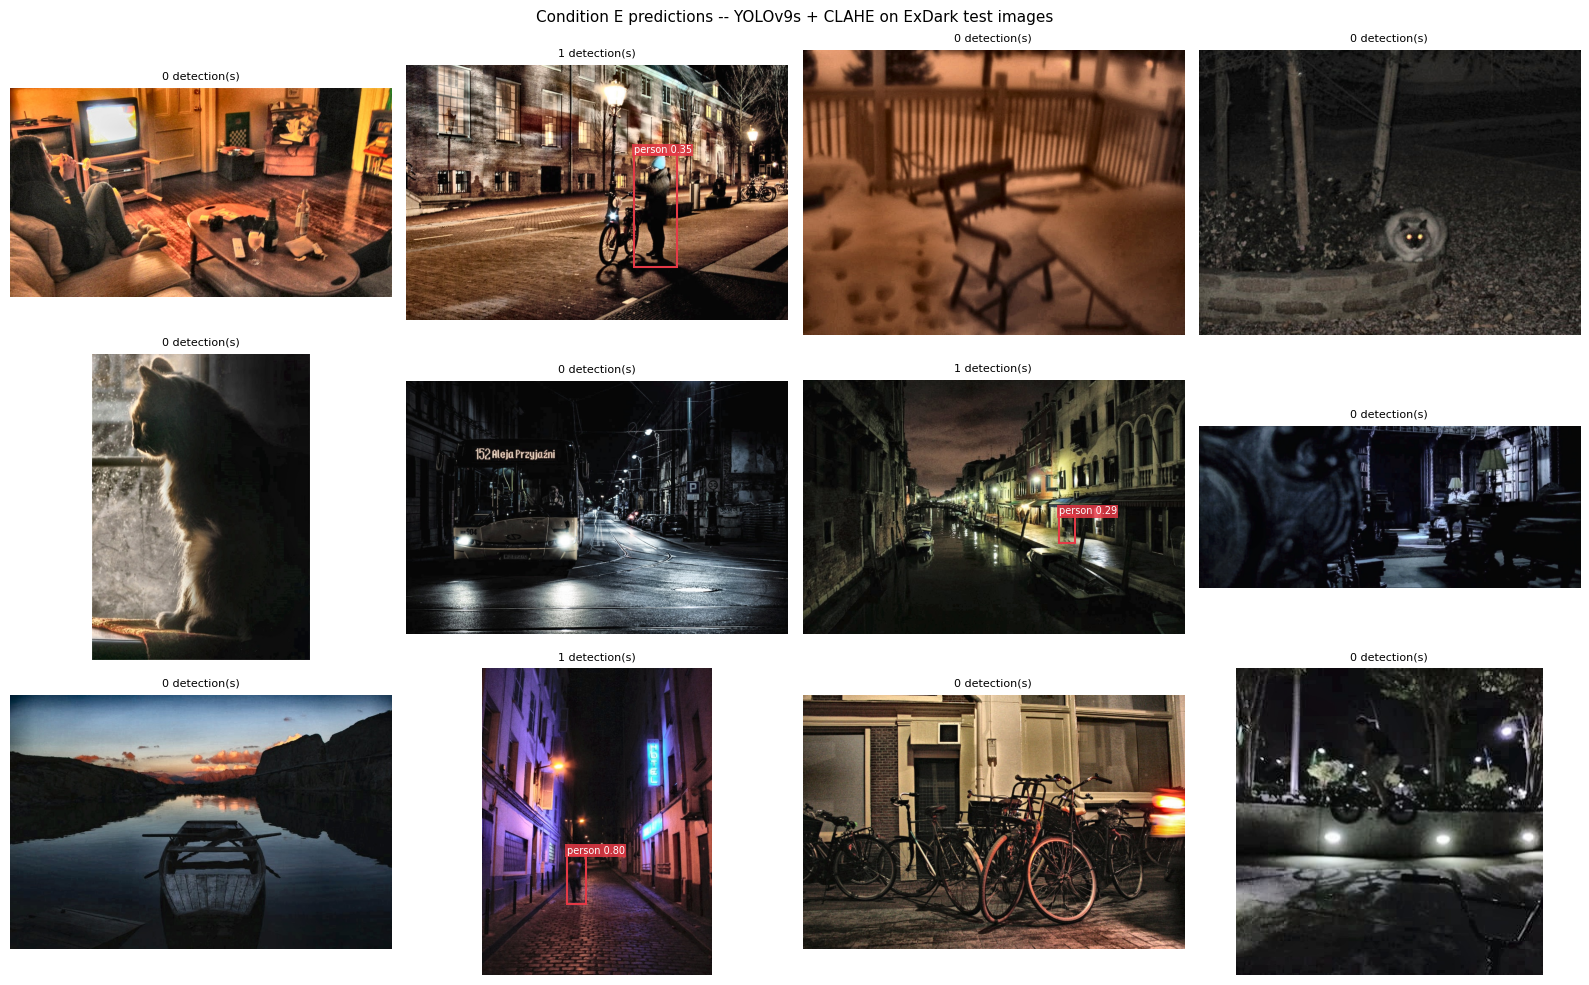

Saved fig_qualitative_predictions.png


In [17]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import random

model = YOLO("/kaggle/working/runs_train/run_E_yolov9_clahe/weights/best.pt")
FIGS = Path("/kaggle/working/figures")
FIGS.mkdir(exist_ok=True)

test_dir = Path("/kaggle/working/exdark_person_dataset_clahe/test/images")
imgs = sorted(test_dir.glob("*.jpg")) + sorted(test_dir.glob("*.png"))
random.seed(42)
sample = random.sample(imgs, 12)

results = model.predict(
    source=[str(p) for p in sample],
    conf=0.25, iou=0.45, save=False, verbose=False
)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for ax, (imgp, res) in zip(axes, zip(sample, results)):
    img = Image.open(imgp).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    n_det = len(res.boxes) if res.boxes is not None else 0
    if res.boxes is not None:
        for box in res.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cf = float(box.conf[0])
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor="#E63946", facecolor="none"
            ))
            ax.text(x1, y1 - 3, f"person {cf:.2f}", color="white", fontsize=7,
                    bbox=dict(facecolor="#E63946", edgecolor="none", pad=1, alpha=0.85))
    ax.set_title(f"{n_det} detection(s)", fontsize=8)

fig.suptitle("Condition E predictions -- YOLOv9s + CLAHE on ExDark test images", fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / "fig_qualitative_predictions.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved fig_qualitative_predictions.png")

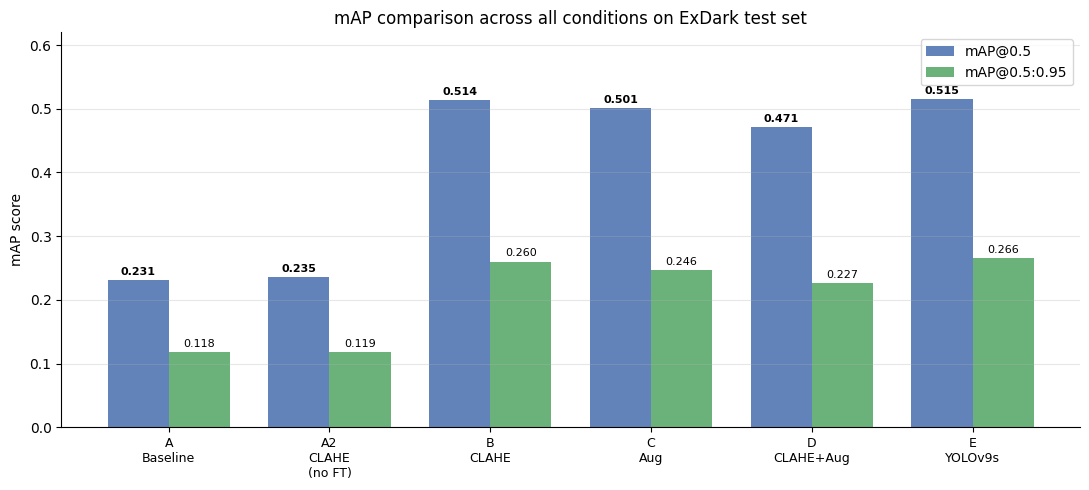

Saved fig_map_comparison.png


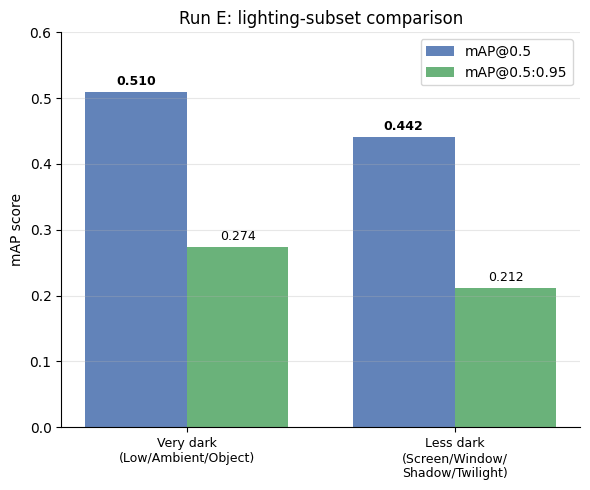

Saved fig_daynight_subset_comparison.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("/kaggle/working/figures")
FIGS.mkdir(exist_ok=True)

conditions = ["A\nBaseline", "A2\nCLAHE\n(no FT)", "B\nCLAHE", "C\nAug", "D\nCLAHE+Aug", "E\nYOLOv9s"]
map50 = [0.2307, 0.2353, 0.5144, 0.5008, 0.4707, 0.5148]
map95 = [0.1182, 0.1188, 0.2601, 0.2464, 0.2265, 0.2663]

x = np.arange(len(conditions))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, map50, w, label="mAP@0.5", color="#4C72B0", alpha=0.88)
ax.bar(x + w/2, map95, w, label="mAP@0.5:0.95", color="#55A868", alpha=0.88)

for i, v in enumerate(map50):
    ax.text(i - w/2, v + 0.008, f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")
for i, v in enumerate(map95):
    ax.text(i + w/2, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=9)
ax.set_ylabel("mAP score")
ax.set_ylim(0, 0.62)
ax.set_title("mAP comparison across all conditions on ExDark test set")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "fig_map_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_map_comparison.png")

# Second small chart: day/night subset gap (Run E)
subsets = ["Very dark\n(Low/Ambient/Object)", "Less dark\n(Screen/Window/\nShadow/Twilight)"]
subset_map50 = [0.5100, 0.4415]
subset_map95 = [0.2741, 0.2116]

x2 = np.arange(len(subsets))
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.bar(x2 - w/2, subset_map50, w, label="mAP@0.5", color="#4C72B0", alpha=0.88)
ax2.bar(x2 + w/2, subset_map95, w, label="mAP@0.5:0.95", color="#55A868", alpha=0.88)

for i, v in enumerate(subset_map50):
    ax2.text(i - w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
for i, v in enumerate(subset_map95):
    ax2.text(i + w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

ax2.set_xticks(x2)
ax2.set_xticklabels(subsets, fontsize=9)
ax2.set_ylabel("mAP score")
ax2.set_ylim(0, 0.6)
ax2.set_title("Run E: lighting-subset comparison")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "fig_daynight_subset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_daynight_subset_comparison.png")